# <div align="center"><b> Detección de palmeras mediante YoloV11 </b></div>

<div align="right">

<!-- [![Binder](http://mybinder.org/badge.svg)](https://mybinder.org/) -->
[![nbviewer](https://img.shields.io/badge/render-nbviewer-orange?logo=Jupyter)](https://nbviewer.org)
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://githubtocolab.com)

</div>

* * *

<style>
/* Limitar la altura de las celdas de salida en html */
.jp-OutputArea.jp-Cell-outputArea {
    max-height: 500px;
}
</style>

🛻 <em><font color='MediumSeaGreen'>  Instalaciones: </font></em> 🛻

Este notebook utiliza [Poetry](https://python-poetry.org/) para la gestión de dependencias.
Primero instala Poetry siguiendo las instrucciones de su [documentación oficial](https://python-poetry.org/docs/#installation).
Luego ejecuta el siguiente comando para instalar las dependencias necesarias y activar el entorno virtual:

- Bash:
```bash
poetry install
eval $(poetry env activate)
```

- PowerShell:
```powershell
poetry install
Invoke-Expression (poetry env activate)
```

In [1]:
# Chequear versión de CUDA
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2024 NVIDIA Corporation
Built on Thu_Jun__6_02:18:23_PDT_2024
Cuda compilation tools, release 12.5, V12.5.82
Build cuda_12.5.r12.5/compiler.34385749_0


In [2]:
# Chequear más datos sobre la GPU
!nvidia-smi

Sun Sep 28 06:59:40 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   32C    P0             58W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

✋ <em><font color='DodgerBlue'>Importaciones:</font></em> ✋

In [ ]:
!pip install ultralytics mlflow python-dotenv loguru requests

In [4]:
!pip uninstall -y albumentations

In [5]:
from google.colab import drive
drive.mount('/content/drive')

import os
from pathlib import Path
from dotenv import load_dotenv
from loguru import logger as LOGGER
from dataclasses import dataclass

OPENCV_IO_MAX_IMAGE_PIXELS = 50000 * 50000  # Para imágenes grandes, ej: barrio3Ombues_20180801_dji_pc_3cm.jpg
os.environ["OPENCV_IO_MAX_IMAGE_PIXELS"] = str(OPENCV_IO_MAX_IMAGE_PIXELS)

# Colab
PROJECT_DIR = Path('/content/drive/MyDrive/ModuloIA/modulo_ia')
# PROJECT_DIR = Path(__file__).resolve().parent
ROOT_DIR = PROJECT_DIR.parent

env_dev_path = PROJECT_DIR / ".env.dev"
env_prod_path = PROJECT_DIR / ".env.prod"

LOGGER.info(f"Directorio de configuración raíz: {ROOT_DIR}")
LOGGER.info(f"Directorio de configuración del proyecto: {PROJECT_DIR}")

if env_dev_path.exists():
    load_dotenv(env_dev_path)
    LOGGER.info("Variables de entorno cargadas desde .env.dev.")
elif env_prod_path.exists():
    load_dotenv(env_prod_path)
    LOGGER.info("Variables de entorno cargadas desde .env.prod.")
else:
    LOGGER.info("No se encontraron archivos .env. Cargando variables desde el entorno del sistema.")


@dataclass
class FoldersConfig:
    data_folder: Path = ROOT_DIR / "data"
    models_folder: Path = ROOT_DIR / "models"
    palm_detection_yolov11_folder: Path = ROOT_DIR / "notebooks" / "deteccion_palmeras" / "yolov11"
    rpw_detection_yolov11_folder: Path = ROOT_DIR / "notebooks" / "deteccion_picudo_rojo" / "yolov11"

    def __post_init__(self):
        self.raw_data_folder: Path = self.data_folder / "raw"
        self.external_data_folder: Path = self.data_folder / "external"
        self.interim_data_folder: Path = self.data_folder / "interim"
        self.processed_data_folder: Path = self.data_folder / "processed"
        self.temp_data_folder: Path = self.data_folder / "temp"


@dataclass
class NamesConfig:
    palm_dataset_name: str = "coco_palm_dataset"


@dataclass
class VersionsConfig:
    palm_dataset_name: str = "v1.0"
    v11: str = "v1.1"


@dataclass
class DatasetsProcessedFormatConfig:
    yolo: str = "yolo"
    huggingface: str = "huggingface"


@dataclass
class FiftyoneConfig:
    host: str
    port: int
    data_quality_folder: Path = ROOT_DIR.parent / "modulo-calidad-datos" / "fiftyone" / "data"

    def __post_init__(self):
        self.address: str = f"http://{self.host}:{self.port}"


@dataclass
class MLFlowConfig:
    host: str
    port: int
    mlflow_tracking_username: str
    mlflow_tracking_password: str
    schema: str

    def __post_init__(self):
        self.tracking_uri: str = f"{self.schema}://{self.host}:{self.port}"


class Config:
    """Clase principal de configuración del sistema"""

    def __init__(self):
        # Configuración general
        self.environment = os.getenv("ENVIRONMENT", "dev")
        self.seed = 42

        self.folders = FoldersConfig()
        self.names = NamesConfig()
        self.versions = VersionsConfig()
        self.datasets_processed_format = DatasetsProcessedFormatConfig()
        self.fiftyone = self._get_fiftyone_config()
        self.mlflow = self._get_mlflow_config()

    def _get_fiftyone_config(self) -> FiftyoneConfig:
        """Obtiene la configuración de FiftyOne desde las variables de entorno"""
        return FiftyoneConfig(host=os.getenv("FIFTYONE_HOST", "localhost"), port=int(os.getenv("FIFTYONE_PORT", 5151)))

    def _get_mlflow_config(self) -> MLFlowConfig:
        """Obtiene la configuración de MLflow desde las variables de entorno"""
        return MLFlowConfig(
            host=os.getenv("MLFLOW_HOST", "localhost"),
            port=int(os.getenv("MLFLOW_PORT", 5000)),
            schema=os.getenv("MLFLOW_SCHEMA", "http"),
            mlflow_tracking_username=os.getenv("MLFLOW_TRACKING_USERNAME", ""),
            mlflow_tracking_password=os.getenv("MLFLOW_TRACKING_PASSWORD", ""),
        )


# If tqdm is installed, configure loguru with tqdm.write
# https://github.com/Delgan/loguru/issues/135
try:
    from tqdm import tqdm

    LOGGER.remove(1)
    LOGGER.add(lambda msg: tqdm.write(msg, end=""), colorize=True)
except Exception:
    pass

# Instancia global de configuración
CONFIG = Config()

# visualizations.py
import pandas as pd
import matplotlib.pyplot as plt
from typing import Union

class TrainingVisualizer:
    def __init__(self, data: Union[str, pd.DataFrame]):
        """
        Inicializa el visualizador.
        Args:
            data: Puede ser una ruta a un archivo CSV (str) o un DataFrame de Pandas.
        """
        if isinstance(data, str):
            self.results_df = pd.read_csv(data).set_index("epoch")
        elif isinstance(data, pd.DataFrame):
            if "epoch" in data.columns:
                self.results_df = data.set_index("epoch")
            else:
                self.results_df = data
        else:
            raise ValueError("El parámetro 'data' debe ser una ruta CSV o un DataFrame de Pandas.")

    def plot_losses(self, save_path: str = None):
        """Subplots para las pérdidas de entrenamiento y validación"""
        fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

        losses = ["box_loss", "cls_loss", "dfl_loss"]
        for ax, loss in zip(axes, losses):
            ax.plot(self.results_df.index, self.results_df[f"train/{loss}"], label=f"train/{loss}")
            ax.plot(self.results_df.index, self.results_df[f"val/{loss}"], label=f"val/{loss}")
            ax.set_ylabel("Loss")
            ax.set_title(loss)
            ax.legend()
            ax.grid(True)

        axes[-1].set_xlabel("Epoch")
        fig.suptitle("Entrenamiento y Validación - Pérdidas", fontsize=14)

        if save_path:
            plt.savefig(save_path, bbox_inches="tight")
        else:
            plt.show()
        plt.close()

    def plot_metrics(self, save_path: str = None):
        """Subplots para métricas de validación"""
        fig, axes = plt.subplots(4, 1, figsize=(10, 16), sharex=True)

        metrics = [
            ("metrics/precision(B)", "Precision"),
            ("metrics/recall(B)", "Recall"),
            ("metrics/mAP50(B)", "mAP@50"),
            ("metrics/mAP50-95(B)", "mAP@50-95"),
        ]

        for ax, (col, title) in zip(axes, metrics):
            ax.plot(self.results_df.index, self.results_df[col], label=title)
            ax.set_ylabel("Valor")
            ax.set_title(title)
            ax.legend()
            ax.grid(True)

        axes[-1].set_xlabel("Epoch")
        fig.suptitle("Métricas de Validación", fontsize=14)

        if save_path:
            plt.savefig(save_path, bbox_inches="tight")
        else:
            plt.show()
        plt.close()

    def plot_lr(self, save_path: str = None):
        """Subplots para learning rate"""
        fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

        lrs = ["lr/pg0", "lr/pg1", "lr/pg2"]
        for ax, lr in zip(axes, lrs):
            ax.plot(self.results_df.index, self.results_df[lr], label=lr)
            ax.set_ylabel("LR")
            ax.set_title(lr)
            ax.legend()
            ax.grid(True)

        axes[-1].set_xlabel("Epoch")
        fig.suptitle("Tasas de Aprendizaje por Grupo de Parámetros", fontsize=14)

        if save_path:
            plt.savefig(save_path, bbox_inches="tight")
        else:
            plt.show()
        plt.close()

    def plot_all(self, save_dir: str = None):
        """Genera todas las gráficas"""
        if save_dir:
            self.plot_losses(f"{save_dir}/losses.png")
            self.plot_metrics(f"{save_dir}/metrics.png")
            self.plot_lr(f"{save_dir}/lr.png")
        else:
            self.plot_losses()
            self.plot_metrics()
            self.plot_lr()

2025-09-28 06:59:47.934 | INFO     | __main__:<cell line: 0>:21 - Directorio de configuración raíz: /content/drive/MyDrive/ModuloIA
2025-09-28 06:59:47.935 | INFO     | __main__:<cell line: 0>:22 - Directorio de configuración del proyecto: /content/drive/MyDrive/ModuloIA/modulo_ia
2025-09-28 06:59:47.940 | INFO     | __main__:<cell line: 0>:26 - Variables de entorno cargadas desde .env.dev.


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
os.environ["ALBUMENTATIONS_DISABLE"] = "1" # Deshabilita Albumentations por defecto.
import sys, json, requests, os, shutil, yaml, random, zipfile, time
from pathlib import Path
from pprint import pprint
import ultralytics
from ultralytics import YOLO, settings
from ultralytics.data.utils import visualize_image_annotations
import torch
import mlflow
import PIL

🔧 <em><font color='tomato'>Configuraciones:</font></em> 🔧


In [7]:
# CONFIGURACIONES GENERALES
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"  # Establece el dispositivo.
LOGGER.remove()
LOGGER.add(sys.stderr, level="INFO")
PIL.Image.MAX_IMAGE_PIXELS = None

# COMPORTAMIENTO DEL NOTEBOOK
SHOULD_PROCESS_DATASET = False  # Descarga el dataset completo
SHOULD_TRAIN = True  # Entrenamiento
SHOULD_SEARCH_HYPERPARAMETERS = False  # Búsqueda de hiperparámetros
IS_IN_COLAB = True

# CARPETAS
RAW_DATA_FOLDER = CONFIG.folders.raw_data_folder
EXTERNAL_DATA_FOLDER = CONFIG.folders.external_data_folder
INTERIM_DATA_FOLDER = CONFIG.folders.interim_data_folder
PROCESSED_DATA_FOLDER = CONFIG.folders.processed_data_folder
DATA_FOLDER = CONFIG.folders.data_folder
DOWNLOAD_COCO_ANNOTATIONS_FOLDER = Path("downloads") / "coco_annotations"  # Carpeta para descargar anotaciones COCO
DOWNLOAD_PREDICTION_FOLDER = Path("downloads") / "predictions"  # Carpeta para descargar parches de prueba
MODEL_FOLDER = CONFIG.folders.models_folder
PALM_DETECTION_YOLOV11_FOLDER = CONFIG.folders.palm_detection_yolov11_folder

# CONFIGURACIONES DE ENTRENAMIENTO
BATCH_SIZE = 64  # 16 -> Yolo11x | # 64 -> Yolo11n
N_EPOCHS = 350  # Número de épocas
VERBOSE = True  # Muestra época a época la evolución
IMG_SIZE = 640  # Tamaño de la imagen
RANDOM_SEED = CONFIG.seed  # Semilla para la aleatoriedad
CROP_THRESHOLD = 0.2  # Umbral de inclusión de etiquetas en recortes
CROP_OVERLAP = 250  # Solapamiento entre recortes
BACKGROUND_PERCENTAGE = 0.1  # Porcentaje de fondo en el dataset balanceado
FREEZE_LAYERS = 0  # Número de capas a congelar
EARLY_STOPPING = 20  # Paciencia para el early stopping

# DATA AUGMENTATIONS
# Opciones: train_no_aumentations.yaml | train_custom1_aumentations.yaml | train_custom2_aumentations.yaml
AUMENTATIONS_CONFIG_FILE_NAME = "train_custom1_aumentations"
AUMENTATIONS_CONFIG_FILE_PATH = PALM_DETECTION_YOLOV11_FOLDER / f"{AUMENTATIONS_CONFIG_FILE_NAME}.yaml"
CUSTOM_TRANSFORMS = [AUMENTATIONS_CONFIG_FILE_NAME]

# TAREA
TASK_NAME = "palm_detection"
CLASS_NAMES = {0: "palmera"}
COLOR_MAP = {
    "palmera": (0, 255, 0),  # Verde
}
CATEGORIES = [{"id": id, "name": name, "supercategory": ""} for id, name in CLASS_NAMES.items()]

# MODELO
MODEL_NAME = "yolo11x"
# Opciones: f"{MODEL_NAME}.pt" | Ruta al checkpoint personalizado
MODEL_CHECKPOINT = f"{MODEL_NAME}.pt"

# DATOS DEL DATASET
DATASET_NAME = CONFIG.names.palm_dataset_name
DATASET_VERSION = CONFIG.versions.v11
DATASET_IDENTIFIER = f"{DATASET_NAME}_{DATASET_VERSION}"
DATASET_FINAL_FORMAT = CONFIG.datasets_processed_format.yolo  # Formato final del dataset procesado

# RUTAS Y NOMBRES
DATASET_RAW_NAME = DATASET_IDENTIFIER
DATASET_RAW_PATH = RAW_DATA_FOLDER / DATASET_RAW_NAME
DATASET_INTERIM_NAME = DATASET_IDENTIFIER
DATASET_INTERIM_PATH = INTERIM_DATA_FOLDER / DATASET_INTERIM_NAME
DATASET_INTERIM_STEP_PATH = INTERIM_DATA_FOLDER / f"{DATASET_INTERIM_NAME}_step"
DATASET_INTERIM_STEP_NAME = f"{DATASET_INTERIM_NAME}_step"
DATASET_PROCESSED_NAME = f"{DATASET_IDENTIFIER}_{TASK_NAME}_{DATASET_FINAL_FORMAT}"
DATASET_PROCESSED_PATH = PROCESSED_DATA_FOLDER / DATASET_PROCESSED_NAME
EXPERIMENT_NAME = f"{TASK_NAME}_{MODEL_NAME.replace('/', '_')}_{IMG_SIZE}"
EXPERIMENT_PATH = PALM_DETECTION_YOLOV11_FOLDER / EXPERIMENT_NAME
EXPERIMENT_HYPERPARAMETER_SEARCH_PATH = PALM_DETECTION_YOLOV11_FOLDER / f"{EXPERIMENT_NAME}_hyperparameter_search"

# RESULTADOS
MODELS_PERFORMANCE_RESULTS = []

# MLFLOW
MLFLOW_URL = CONFIG.mlflow.tracking_uri
MLFLOW_TRACKING_USERNAME = CONFIG.mlflow.mlflow_tracking_username
MLFLOW_TRACKING_PASSWORD = CONFIG.mlflow.mlflow_tracking_password
os.environ["MLFLOW_TRACKING_URI"] = MLFLOW_URL  # Configura la URI de seguimiento de MLflow.
os.environ["MLFLOW_TRACKING_USERNAME"] = MLFLOW_TRACKING_USERNAME  # Configura el nombre de usuario para MLflow.
os.environ["MLFLOW_TRACKING_PASSWORD"] = MLFLOW_TRACKING_PASSWORD  # Config
os.environ["MLFLOW_TAGS"] = '{"model_family": "palm_detection"}'  # Configura las etiquetas del experimento de MLflow.
settings.update({"mlflow": True})  # Habilita el uso de MLflow en ultralytics

# COMPROBACIONES
ultralytics.checks()  # Verifica la instalación de ultralytics
LOGGER.info(f"Dispositivo actual: {DEVICE}")

Ultralytics 8.3.203 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (NVIDIA A100-SXM4-80GB, 81222MiB)
Setup complete ✅ (12 CPUs, 167.1 GB RAM, 45.1/235.7 GB disk)


2025-09-28 06:59:51.215 | INFO     | __main__:<cell line: 0>:89 - Dispositivo actual: cuda


<div align="center">✨Datos del proyecto:✨</div>

<p></p>

<div align="center">

| **Subtitulo**   | Detección de palmeras - YoloV11                                                                                                        |
| --------------- | -------------------------------------------------------------------------------------------------------------------------------------- |
| **Descrpción**  | <small>Notebook de detección de palmeras utilizando YoloV11</small>                                                                    |

</div>

## Chequeo de conexiones

In [8]:
# Chequeo de conexión a MLflow
LOGGER.info(f"Conectando a MLflow en {MLFLOW_URL}...")
try:
    response = requests.get(MLFLOW_URL)
    response.raise_for_status()  # Verifica si la solicitud fue exitosa.
    LOGGER.success("Conexión a MLflow establecida correctamente.")

except Exception as e:
    LOGGER.error(f"Error al conectar con MLflow. Tienes levantado el servidor de MLflow?")
    raise SystemExit(f"Error al conectar con MLflow: {e}")

# if SHOULD_PROCESS_DATASET:
#     # Chequeo de conexión a MinIO
#     LOGGER.info("Chequeando conexión a MinIO...")
#     ProcesadorS3.test_connection()

# # Chequeo de conexión a MongoDB
# LOGGER.info("Chequeando conexión a MongoDB...")
# ProcesadorAnotacionesMongoDB.test_connection()
# LOGGER.success("Conexión a MongoDB verificada correctamente.")

2025-09-28 06:59:51.222 | INFO     | __main__:<cell line: 0>:2 - Conectando a MLflow en https://da5be664abfa.ngrok-free.app:443...
2025-09-28 06:59:51.729 | SUCCESS  | __main__:<cell line: 0>:6 - Conexión a MLflow establecida correctamente.


## Raw dataset

In [9]:
# if DATASET_RAW_PATH.exists():
#     LOGGER.info("Dataset ya descargado. Procesando dataset...")

#     dataset_metrics = DatasetProcessor.get_dataset_metrics(
#         dataset_path=DATASET_RAW_PATH, dataset_name=DATASET_RAW_NAME, dataset_format=DatasetProcessor.DatasetFormat.COCO
#     )
#     dataset_stats = DatasetProcessor.get_dataset_stats(
#         dataset_path=DATASET_RAW_PATH, dataset_name=DATASET_RAW_NAME, dataset_format=DatasetProcessor.DatasetFormat.COCO
#     )
#     LOGGER.info(f"Metricas del dataset:\n {json.dumps(dataset_metrics, indent=2)}")
#     LOGGER.info(f"Estadísticas del dataset:\n {json.dumps(dataset_stats, indent=2)}")
# else:
#     LOGGER.error(f"El dataset no fue encontrado en {DATASET_RAW_PATH}. Tienes que descargarlo previamente.")
#     sys.exit(1)

## Procesamiento del dataset

### Convertir todas las clases a una sola

In [10]:
CUSTOM_TRANSFORMS.append("delete_label: palmera-exterminada")  # Agrega la transformación de eliminación de etiqueta
CUSTOM_TRANSFORMS.append("assign_to_single_label: palmera")  # Agrega la transformación de asignación de etiqueta
# if SHOULD_PROCESS_DATASET:
#     LOGGER.info("Cambiando la etiqueta del dataset a 'palmera'...")
#     # Copiamos el dataset a la carpeta de datos
#     shutil.copytree(DATASET_RAW_PATH, DATASET_INTERIM_PATH, dirs_exist_ok=True)

#     json_folder = DATASET_INTERIM_PATH
#     coco_anotations = CocoDatasetUtils.load_annotations_from_path(json_folder / "labels.json")

#     LOGGER.info("Eliminando etiqueta 'palmera-exterminada'...")
#     coco_anotations = CocoDatasetUtils.delete_label(coco_anotations, "palmera-exterminada")


#     LOGGER.info("Asignando la etiqueta 'palmera' a todas las anotaciones...")
#     coco_annotations_one_class = CocoDatasetUtils.assign_to_single_label(coco_anotations, CLASS_NAMES[0])


#     with open(json_folder / "labels.json", "w") as f:
#         json.dump(coco_annotations_one_class, f, indent=4)
#         LOGGER.info(f"Se copió el dataset y se guardó el archivo de etiquetas en {json_folder / 'labels.json'}")

#     LOGGER.info(f"Nuevas categorías:\n {json.dumps(coco_anotations['categories'], indent=2)}")

### Convertir dataset a formato YOLO
<small><em>https://docs.ultralytics.com/reference/cfg/__init__/</em></small>

In [11]:
# if SHOULD_PROCESS_DATASET:
#     LOGGER.info("Convirtiendo el dataset a formato de modelo...")
#     DatasetProcessor.convert_dataset_to_model_format(dataset_path=DATASET_INTERIM_PATH, output_dir=DATASET_INTERIM_STEP_PATH, clean=True)

Ejemplo con views splits:

```python
for split in splits:
    split_view = dataset_or_view.match_tags(split)
    split_view.export(
        export_dir=export_dir,
        dataset_type=fo.types.YOLOv5Dataset,
        label_field=label_field,
        split=split,
        classes=classes,
    )
```

### Recortar el dataset en imágenes pequeñas

In [12]:
CUSTOM_TRANSFORMS.append(f"crop threshold: {CROP_THRESHOLD}")  # Agrega la transformación de recorte
CUSTOM_TRANSFORMS.append(f"crop overlap: {CROP_OVERLAP}")  # Agrega la transformación de recorte
# if SHOULD_PROCESS_DATASET:
#     LOGGER.info("Cortando el dataset para entrenamiento...")
#     FeaturesProcessor.crop_dataset(
#         dataset_path=DATASET_INTERIM_STEP_PATH, crop_size=IMG_SIZE, overlap=CROP_OVERLAP, threshold=CROP_THRESHOLD
#     )

#     dataset_metrics = DatasetProcessor.get_dataset_metrics(
#         dataset_path=DATASET_INTERIM_STEP_PATH,
#         dataset_name=DATASET_INTERIM_STEP_NAME,
#         dataset_format=DatasetFormat.YOLO,
#     )

#     LOGGER.info(f"Metricas del dataset:\n {json.dumps(dataset_metrics, indent=2)}")

### Balancear el dataset

In [13]:
CUSTOM_TRANSFORMS.append(f"background percentage: {BACKGROUND_PERCENTAGE}")  # Agrega la transformación de balanceo
# if SHOULD_PROCESS_DATASET:
#     LOGGER.info("Balanceando el dataset...")
#     FeaturesProcessor.balance_dataset_v1(
#         dataset_path=DATASET_INTERIM_STEP_PATH,
#         output_path=DATASET_INTERIM_STEP_PATH,
#         all_classes=False,
#         background_percentage=BACKGROUND_PERCENTAGE,
#         export_categories=CATEGORIES,
#     )

#     dataset_metrics = DatasetProcessor.get_dataset_metrics(
#         dataset_path=DATASET_INTERIM_STEP_PATH,
#         dataset_name=DATASET_INTERIM_STEP_NAME,
#         dataset_format=DatasetFormat.YOLO,
#     )
#     LOGGER.info(f"Metricas del dataset:\n {json.dumps(dataset_metrics, indent=2)}")

### Split del dataset

In [14]:
CUSTOM_TRANSFORMS.append("split: 0.8, 0.1, 0.1")  # Agrega la transformación de split
# if SHOULD_PROCESS_DATASET:
#     LOGGER.info("Split del dataset...")
#     DatasetProcessor.split_dataset(dataset_path=DATASET_INTERIM_STEP_PATH, output_dir=DATASET_PROCESSED_PATH, clean=True, ratios=(0.8, 0.1, 0.1))

### Cargar dataset en memoria (Colab)

In [15]:
origin_file = DATASET_PROCESSED_PATH.parent / (DATASET_PROCESSED_PATH.name + '.zip')
target_path = Path("/content")
target_file_path = target_path / DATASET_PROCESSED_NAME
temp_dataset = target_path / DATASET_PROCESSED_NAME
zip_file_path = target_path / (DATASET_PROCESSED_PATH.name + '.zip')
dataset_yaml_path = target_file_path / "dataset.yaml"
new_path = str(target_file_path)
train_path = "images/train"
val_path = "images/val"
test_path = "images/test"

if temp_dataset.exists():
    LOGGER.success(f"El dataset ya existe en Colab.")
else:
    try:
        LOGGER.info(f"Copiando el dataset a {target_path}...")
        start_time = time.time()
        shutil.copy(origin_file, target_path)
        end_time = time.time()
        copy_time = end_time - start_time
        LOGGER.success(f"✅ Archivo copiado exitosamente a: {target_path}. Tiempo: {copy_time:.2f} segundos")
        try:
            LOGGER.info(f"Descomprimiendo el archivo {zip_file_path}...")
            start_time = time.time()
            with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
                zip_ref.extractall(target_file_path)
            end_time = time.time()
            unzip_time = end_time - start_time
            LOGGER.success(f"✅ Archivo '{zip_file_path}' descomprimido exitosamente en: {target_file_path}. Tiempo: {unzip_time:.2f} segundos")
            zip_file_path.unlink()
            LOGGER.success(f"✅ Archivo '{zip_file_path}' eliminado exitosamente.")
            try:
                with open(dataset_yaml_path, 'r') as f:
                    data_yaml = yaml.safe_load(f)
                data_yaml['path'] = new_path
                data_yaml['train'] = train_path
                data_yaml['val'] = val_path
                data_yaml['test'] = test_path
                with open(dataset_yaml_path, 'w') as f:
                    yaml.dump(data_yaml, f, sort_keys=False)
                LOGGER.success(f"✅ dataset.yaml en Drive modificado. La clave 'path' es ahora: {new_path}")
            except Exception as e:
                LOGGER.error(f"❌ Error al modificar {dataset_yaml_path}: {e}.")
        except Exception as e:
            raise Exception(f"❌ Error al descomprimir el archivo: {e}")
        except FileNotFoundError:
            raise Exception(f"❌ Error: El archivo ZIP no fue encontrado en: {zip_file_path}")
        except zipfile.BadZipFile:
            raise Exception(f"❌ Error: El archivo '{zip_file_path}' está corrupto o no es un archivo ZIP válido.")
        except Exception as e:
            raise Exception(f"❌ Ocurrió un error al descomprimir el archivo: {e}")
    except FileNotFoundError:
        raise Exception(f"El archivo {origin_file} no fue encontrado.")
    except Exception as e:
        raise Exception(f"Error al copiar el archivo: {e}")
DATASET_PROCESSED_PATH = target_file_path

2025-09-28 06:59:51.770 | SUCCESS  | __main__:<cell line: 0>:13 - El dataset ya existe en Colab.


### Validaciones del dataset

#### Existencia del archivo dataset.yaml

In [16]:
dataset_yaml_path = DATASET_PROCESSED_PATH / "dataset.yaml"
if not dataset_yaml_path.exists():
    raise FileNotFoundError(f"El archivo {dataset_yaml_path} no existe. Asegúrate de que el dataset se haya procesado correctamente.")
LOGGER.success(f"Archivo dataset.yaml encontrado en {dataset_yaml_path}")

2025-09-28 06:59:51.776 | SUCCESS  | __main__:<cell line: 0>:4 - Archivo dataset.yaml encontrado en /content/coco_palm_dataset_v1.1_palm_detection_yolo/dataset.yaml


#### Congruencia de las clases

In [17]:
with open(dataset_yaml_path, "r") as f:
    dataset_yaml = yaml.safe_load(f)
    LOGGER.debug(f"Dataset YAML cargado: {dataset_yaml}")

DATASET_YAML_CLASS_NAMES = dataset_yaml["names"]
if set(DATASET_YAML_CLASS_NAMES.values()) != set(CLASS_NAMES.values()):
    raise ValueError(f"Las clases del dataset YAML {DATASET_YAML_CLASS_NAMES} no coinciden con las esperadas {CLASS_NAMES.values()}.")

LOGGER.success("Validaciones de clases realizadas correctamente.")

2025-09-28 06:59:51.782 | SUCCESS  | __main__:<cell line: 0>:9 - Validaciones de clases realizadas correctamente.


### Metricas del dataset procesado

In [18]:
# dataset_metrics = DatasetProcessor.get_dataset_metrics(
#     dataset_path=DATASET_PROCESSED_PATH,
#     dataset_name=DATASET_PROCESSED_NAME,
#     dataset_format=DatasetProcessor.DatasetFormat.YOLO,
# )
dataset_metrics_json = {
  "train_count": 13079,
  "train_images_with_detections": 11872,
  "train_images_without_detections": 1207,
  "train_class_count": {
    "palmera": 21094
  },
  "val_count": 1635,
  "val_images_with_detections": 1490,
  "val_images_without_detections": 145,
  "val_class_count": {
    "palmera": 2697
  },
  "test_count": 1635,
  "test_images_with_detections": 1501,
  "test_images_without_detections": 134,
  "test_class_count": {
    "palmera": 2697
  },
  "total_count": 16349,
  "total_images_with_detections": 14863,
  "total_images_without_detections": 1486,
  "total_class_count": {
    "palmera": 26488
  }
}
LOGGER.info(f"Metricas del dataset:\n {dataset_metrics_json}")

2025-09-28 06:59:51.788 | INFO     | __main__:<cell line: 0>:32 - Metricas del dataset:
 {'train_count': 13079, 'train_images_with_detections': 11872, 'train_images_without_detections': 1207, 'train_class_count': {'palmera': 21094}, 'val_count': 1635, 'val_images_with_detections': 1490, 'val_images_without_detections': 145, 'val_class_count': {'palmera': 2697}, 'test_count': 1635, 'test_images_with_detections': 1501, 'test_images_without_detections': 134, 'test_class_count': {'palmera': 2697}, 'total_count': 16349, 'total_images_with_detections': 14863, 'total_images_without_detections': 1486, 'total_class_count': {'palmera': 26488}}


### Visualización

#### Observamos el dataset

> 📝 <em><font color='Gray'>Nota:</font></em> Si hay problema de versiones con `FiftyOne`, borrar la base de datos del mismo que se encuentra en: `C:\Users\<usuario>\.fiftyone\`</em>

In [19]:
# if SHOULD_PROCESS_DATASET:
#     dataset = fo.Dataset(name=DATASET_PROCESSED_NAME, overwrite=True)
#     for split in ["train", "val", "test", "full"]:
#         try:
#             dataset.add_dir(
#                 dataset_dir=DATASET_PROCESSED_PATH, dataset_type=fo.types.YOLOv5Dataset, split=split, tags=[split]
#             )
#         except Exception as e:
#             LOGGER.warning(f'Advertencia: no se pudo agregar el split "{split}" al dataset. Error: {e}')
#             pass
#     try:
#         session = fo.launch_app(dataset)
#         session.freeze()
#     except Exception as e:
#         LOGGER.error(f"No se pudo iniciar FiftyOne. Error: {e}")
#         pass

Accedemos a la visualización: <a>http://localhost:5151</a>

#### Observamos algunas imágenes

2025-09-28 06:59:52.042 | INFO     | __main__:<cell line: 0>:10 - Archivo de texto seleccionado para visualización: /content/coco_palm_dataset_v1.1_palm_detection_yolo/labels/train/RGB_MVD_2024_K-29-D-3-P-7_patch_5_crop_91.txt


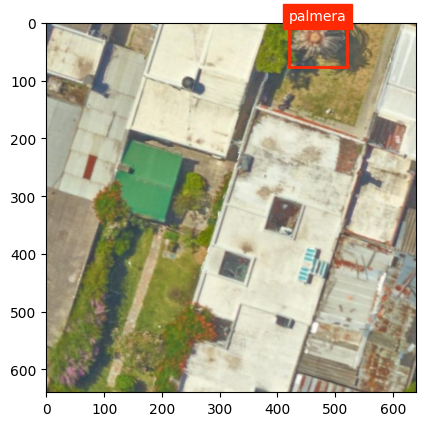

In [20]:
train_image_folder = DATASET_PROCESSED_PATH / "images" / "train"
train_annotations_folder = DATASET_PROCESSED_PATH / "labels" / "train"
# Select one random image from the train folder
if not train_image_folder.exists() or not train_annotations_folder.exists():
    raise FileNotFoundError(f"Las carpetas de entrenamiento no existen: {train_image_folder} o {train_annotations_folder}. Asegúrate de que el dataset se haya procesado correctamente.")
text_files = list(train_annotations_folder.glob("*.txt"))
if not text_files:
    raise FileNotFoundError(f"No se encontraron archivos de texto en {train_annotations_folder}. Asegúrate de que el dataset se haya procesado correctamente.")
text_path = random.choice(text_files)
LOGGER.info(f"Archivo de texto seleccionado para visualización: {text_path}")

image_path = train_image_folder / text_path.with_suffix(".jpg").name
if not image_path.exists():
    raise FileNotFoundError(f"La imagen {image_path} no existe. Asegúrate de que el dataset se haya procesado correctamente.")

category_map = {cat["id"]: cat["name"] for cat in CATEGORIES}

visualize_image_annotations(image_path, text_path, category_map)

#### Observamos el aumento de datos

In [21]:
# yolo_training_dataloader = YoloUtils.get_yolo_training_dataloader(
#     cfg_path=AUMENTATIONS_CONFIG_FILE_PATH,
#     cfg_data=DATASET_PROCESSED_PATH / "dataset.yaml",
#     cfg_imgsz=IMG_SIZE,
#     cfg_batch=9,
#     dataset_path=DATASET_PROCESSED_PATH / "images" / "train",
#     shuffle=True,
# )
# YoloUtils.plot_yolo_augmentations(yolo_training_dataloader, CLASS_NAMES, color_map=COLOR_MAP, max_batches=1)

## Entrenamiento de modelos

$\rightarrow$ Entrenamiento el modelo:
- <small>https://docs.ultralytics.com/yolov5/tutorials/tips_for_best_training_results/#advanced-optimization-techniques</small>
- <small>https://docs.ultralytics.com/guides/yolo-data-augmentation/#introduction</small>

$\rightarrow$ Configuraciones de entrenamiento:
- <small><em>https://docs.ultralytics.com/modes/train/#train-settings</em></small>

$\rightarrow$ Transfer Learning:
- <small>https://www.ultralytics.com/glossary/transfer-learning</small>
- <small>https://docs.ultralytics.com/yolov5/tutorials/transfer_learning_with_frozen_layers/#how-layer-freezing-works</small>
- <small>https://community.ultralytics.com/t/guidance-on-freezing-layers-for-yolov8x-seg-transfer-learning/189</small>

$\rightarrow$ Batch size:
> 📝 <em><font color='Gray'>Nota:</font></em> $\text{Max batch size} = \frac{\text{Available GPU memory (bytes)}}{4 \times (\text{Size of tensors} + \text{Trainable parameters})}$

$\rightarrow$ Hiperparámetros:
- <small><em>https://docs.ultralytics.com/guides/hyperparameter-tuning/</em></small>
- <small><em>https://docs.ultralytics.com/integrations/ray-tune/</em></small>

$\rightarrow$ Ejemplo search grid:
Ejemplo de uso de grid search para hiperparámetros:

```python
from ultralytics import YOLO
import itertools

param_grid = {
    'imgsz': [240, 256, 416],
    'batch': [16, 32, 64],
    'momentum': [0.937, 0.8],
    'optimizer': ['adam', 'adamW'],
}

# Generate combinations
param_combinations = list(itertools.product(*param_grid.values()))

best_map = 0
best_params = {}
for combination in param_combinations:
    params = dict(zip(param_grid.keys(), combination))
    model = YOLO('yolov8n.pt')
    results = model.train(data='coco128.yaml', epochs=50, **params)
    if results['val/mAP_0.5'] > best_map:
        best_map = results['val/mAP_0.5']
        best_params = params

print("Best mAP: {:.4f} with Parameters: {}".format(best_map, best_params))
```

### Datos del modelo base

Checkpoint:

In [22]:
print(f"Checkpoint del modelo base: {MODEL_CHECKPOINT}")
model = YOLO(MODEL_CHECKPOINT)

Checkpoint del modelo base: yolo11x.pt


Resumen de arquitectura:

In [23]:
for name, param in model.named_parameters():
    print(name)

model.model.0.conv.weight
model.model.0.bn.weight
model.model.0.bn.bias
model.model.1.conv.weight
model.model.1.bn.weight
model.model.1.bn.bias
model.model.2.cv1.conv.weight
model.model.2.cv1.bn.weight
model.model.2.cv1.bn.bias
model.model.2.cv2.conv.weight
model.model.2.cv2.bn.weight
model.model.2.cv2.bn.bias
model.model.2.m.0.cv1.conv.weight
model.model.2.m.0.cv1.bn.weight
model.model.2.m.0.cv1.bn.bias
model.model.2.m.0.cv2.conv.weight
model.model.2.m.0.cv2.bn.weight
model.model.2.m.0.cv2.bn.bias
model.model.2.m.0.cv3.conv.weight
model.model.2.m.0.cv3.bn.weight
model.model.2.m.0.cv3.bn.bias
model.model.2.m.0.m.0.cv1.conv.weight
model.model.2.m.0.m.0.cv1.bn.weight
model.model.2.m.0.m.0.cv1.bn.bias
model.model.2.m.0.m.0.cv2.conv.weight
model.model.2.m.0.m.0.cv2.bn.weight
model.model.2.m.0.m.0.cv2.bn.bias
model.model.2.m.0.m.1.cv1.conv.weight
model.model.2.m.0.m.1.cv1.bn.weight
model.model.2.m.0.m.1.cv1.bn.bias
model.model.2.m.0.m.1.cv2.conv.weight
model.model.2.m.0.m.1.cv2.bn.weight
mo

Arquitectura del modelo base:

In [24]:
print(model)

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 96, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(96, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(96, 192, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(192, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C3k2(
        (cv1): Conv(
          (conv): Conv2d(192, 192, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(192, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(384, 384, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(384, eps=0.001, momentum=0.03, affine=True, track_

### Entrenamiento del modelo

In [25]:
model = YOLO(MODEL_CHECKPOINT)

#### Busqueda de hiperparámetros

In [26]:
space_search = {
    "lr0": [0.01, 0.001, 0.0001],  # Learning rate
    "lrf": [0.1, 0.01],  # Learning rate final como una fracción de lr0
    "box": [7.5, 4.0, 0.5],  # Box loss gain
    "cls": [7.5, 4.0, 0.5],  # Class loss gain
    "dfl": [7.5, 4.0, 1.5, 0.5],  # DFL loss gain
}

In [27]:
if SHOULD_SEARCH_HYPERPARAMETERS:
    should_resume = False
    settings.update({"mlflow": False})
    model.tune(
        data=str(DATASET_PROCESSED_PATH / "dataset.yaml"),
        batch=BATCH_SIZE,
        project=EXPERIMENT_HYPERPARAMETER_SEARCH_PATH,
        iterations=300,
        epochs=100,
        space=space_search,
        optimizer="SGD",
        plots=False,
        save=False,
        val=False,
        resume=should_resume,
    )
    settings.update({"mlflow": True})
    should_resume = False

#### Entrenamiento

In [31]:
if SHOULD_TRAIN:
    experiment = mlflow.set_experiment(EXPERIMENT_NAME)
    os.environ["MLFLOW_EXPERIMENT_NAME"] = EXPERIMENT_NAME
    run_id = None

    should_resume = True
    if should_resume:
        model = YOLO(EXPERIMENT_PATH / "train" / "weights" / "last.pt")
        run_id = "a3a50bd4646e4044bed83f02f8bb03f4"

    with mlflow.start_run(experiment_id=experiment.experiment_id, run_id=run_id):
        LOGGER.info(f"🧪 Run ID: {mlflow.active_run().info.run_id}")
        if not should_resume:
            mlflow.log_param("dataset_name", DATASET_NAME)
            mlflow.log_param("dataset_version", DATASET_VERSION)
            mlflow.log_param("dataset_format", DATASET_FINAL_FORMAT)
            mlflow.log_param("dataset_processed_name", DATASET_PROCESSED_NAME)
            mlflow.log_param("dataset_metrics", dataset_metrics_json)
            mlflow.log_param("transforms", ", ".join(CUSTOM_TRANSFORMS))
            mlflow.log_param("model_name", MODEL_NAME)
            mlflow.log_param("model_checkpoint", MODEL_CHECKPOINT)
            mlflow.log_param("img_size", IMG_SIZE)
            mlflow.log_param("crop_threshold", CROP_THRESHOLD)
            mlflow.log_param("background_percentage", BACKGROUND_PERCENTAGE)
            mlflow.log_param("has_resumed", should_resume)
            mlflow.log_param("stage", "full_training")
            mlflow.log_param("freeze_layers", FREEZE_LAYERS)
        else:
            LOGGER.info("♻️ Reanudando entrenamiento de transferencia de aprendizaje...")

        history = model.train(
            cfg=str(AUMENTATIONS_CONFIG_FILE_PATH),  # Configuración de aumentaciones
            data=str(DATASET_PROCESSED_PATH / "dataset.yaml"),
            epochs=N_EPOCHS,
            batch=BATCH_SIZE,
            device=0,  # Usa la GPU 0
            # device="cpu",  # Usa la CPU
            verbose=VERBOSE,  # Muestra época a época la evolución
            imgsz=IMG_SIZE,
            project=EXPERIMENT_PATH,
            exist_ok=True,
            save_period=5,
            patience=20,
            plots=True,
            cache=True,
            # close_mosaic=0,  # Cierra el mosaico de imágenes después de mostrarlo
            # cache=True, # Cachea las imágenes en memoria para acelerar el entrenamiento
            # Parámetros de configuración del entrenamiento
            # optimizer="SGD", # Valores posibles: SGD, Adam, AdamW, NAdam, RAdam, RMSProp. Defecto=auto
            # cos_lr=True, # Usa decaimiento cosenoidal del learning rate
            # lr0=0.1, # Learning rate inicial. Default=0.01
            # lrf=0.01, # Tasa de aprendizaje final como una fracción de la tasa inicial = (lr0 * lrf). Valor alto=menos decaimiento. Default=0.01, 1% del lr0.
            # momentum=0.937, # Factor de momento para SGD o beta1 para optimizadores Adam
            # weight_decay=0.0005 # Peso de decaimiento (L2 regularization)
            # warmup_epochs=3.0, # Número de épocas para el calentamiento de la tasa de aprendizaje (aumenta gradualmente el lr hasta lr0). Defecto: 3.0
            # warmup_momentum=0.8, # Momentum inicial del calentamiento
            # warmup_bias_lr=0.1, # Tasa de aprendizaje para los parámetros de sesgo durante la fase de calentamiento (ayuda a estabilizar el entrenamiento al inicio)
            # dropout=0.0, # Tasa de dropout
            resume=should_resume,
        )
    should_resume = False

2025-09-28 12:48:19.039 | INFO     | __main__:<cell line: 0>:12 - 🧪 Run ID: a3a50bd4646e4044bed83f02f8bb03f4
2025-09-28 12:48:19.040 | INFO     | __main__:<cell line: 0>:29 - ♻️ Reanudando entrenamiento de transferencia de aprendizaje...


Ultralytics 8.3.203 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (NVIDIA A100-SXM4-80GB, 81222MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=True, cfg=/content/drive/MyDrive/ModuloIA/notebooks/deteccion_palmeras/yolov11/train_custom1_aumentations.yaml, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/coco_palm_dataset_v1.1_palm_detection_yolo/dataset.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=350, erasing=0.1, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=/content/drive/MyDrive/ModuloIA/notebooks/deteccion_palmeras/

2025/09/28 12:48:47 WARNING mlflow.spark: With Pyspark >= 3.2, PYSPARK_PIN_THREAD environment variable must be set to false for Spark datasource autologging to work.
2025/09/28 12:48:47 INFO mlflow.tracking.fluent: Autologging successfully enabled for pyspark.


MLflow: logging run_id(a3a50bd4646e4044bed83f02f8bb03f4) to https://da5be664abfa.ngrok-free.app:443
MLflow: disable with 'yolo settings mlflow=False'
WARNING ⚠️ MLflow: Failed to initialize: INVALID_PARAMETER_VALUE: Changing param values is not allowed. Params were already logged='[{'key': 'model', 'old_value': 'yolo11x.pt', 'new_value': '/content/drive/MyDrive/ModuloIA/notebooks/deteccion_palmeras/yolov11/palm_detection_yolo11x_640/train/weights/last.pt'}, {'key': 'resume', 'old_value': 'False', 'new_value': '/content/drive/MyDrive/ModuloIA/notebooks/deteccion_palmeras/yolov11/palm_detection_yolo11x_640/train/weights/last.pt'}]' for run ID='a3a50bd4646e4044bed83f02f8bb03f4'.
WARNING ⚠️ MLflow: Not tracking this run
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to /content/drive/MyDrive/ModuloIA/notebooks/deteccion_palmeras/yolov11/palm_detection_yolo11x_640/train
Starting training for 350 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  I

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 1.4it/s 9.4s
                   all       1635       2697      0.955      0.967      0.981      0.871


KeyboardInterrupt: 

#### Métricas de entrenamiento

In [29]:
if SHOULD_TRAIN:
    try:
        results_df = pd.read_csv(EXPERIMENT_PATH / "train" / "results.csv").set_index("epoch")
        results_df["time_diff"] = results_df["time"].diff().fillna(0)
    except FileNotFoundError:
        LOGGER.warning(
            "No se encontró el archivo results.csv. Asegúrate de que el entrenamiento se completó correctamente."
        )
        results_df = pd.DataFrame()
    except NameError:
        LOGGER.error("El entrenamiento no se realizó correctamente. Verifica los parámetros de entrenamiento.")
        results_df = pd.DataFrame()
    except Exception as e:
        LOGGER.error(f"Error al cargar los resultados del entrenamiento: {e}")
        results_df = pd.DataFrame()
    display(results_df)

,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2,time_diff
epoch,,,,,,,,,,,,,,,
1,197.834,1.32693,1.52415,1.56715,0.86362,0.79362,0.86804,0.55649,1.30616,0.78010,1.50205,0.003317,0.003317,0.003317,0.000
2,374.284,1.23277,0.94515,1.44118,0.83669,0.73378,0.80459,0.50338,1.35996,1.18694,1.66740,0.006632,0.006632,0.006632,176.450
3,551.448,1.34647,1.10409,1.52976,0.39827,0.26066,0.23852,0.10051,2.46310,4.45280,2.53746,0.009927,0.009927,0.009927,177.164
4,728.911,1.40948,1.18388,1.58825,0.79362,0.63877,0.71206,0.42283,1.46669,2.04764,1.69066,0.009915,0.009915,0.009915,177.463
5,906.381,1.34656,1.08166,1.53474,0.82787,0.70449,0.79556,0.47692,1.41617,1.23052,1.63166,0.009887,0.009887,0.009887,177.470
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120,20010.300,0.68909,0.44828,1.07511,0.95358,0.96329,0.97975,0.85527,0.59078,0.28823,1.04520,0.006634,0.006634,0.006634,176.800
121,20186.900,0.68236,0.44468,1.07240,0.95274,0.96417,0.98007,0.85568,0.58967,0.28810,1.04450,0.006606,0.006606,0.006606,176.600
122,20364.200,0.68906,0.44853,1.07401,0.95276,0.96474,0.98012,0.85621,0.58800,0.28770,1.04344,0.006577,0.006577,0.006577,177.300


#### Gráficas de entrenamiento

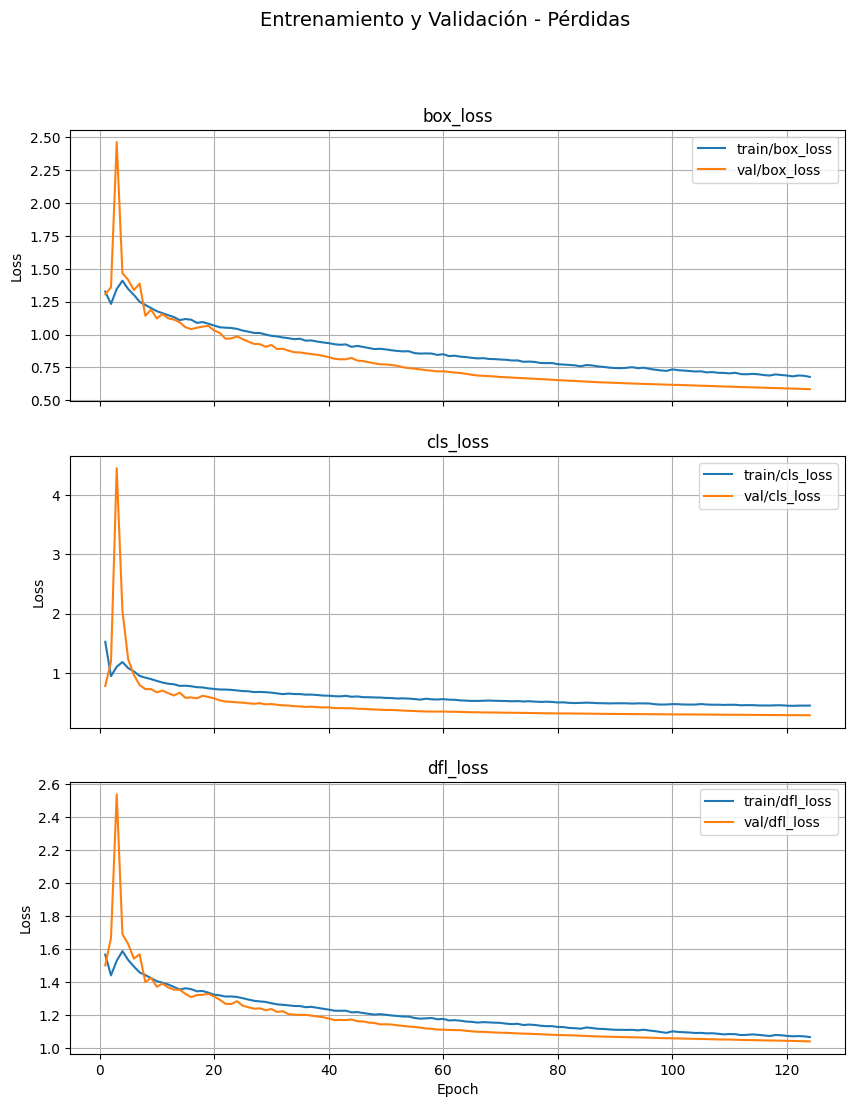

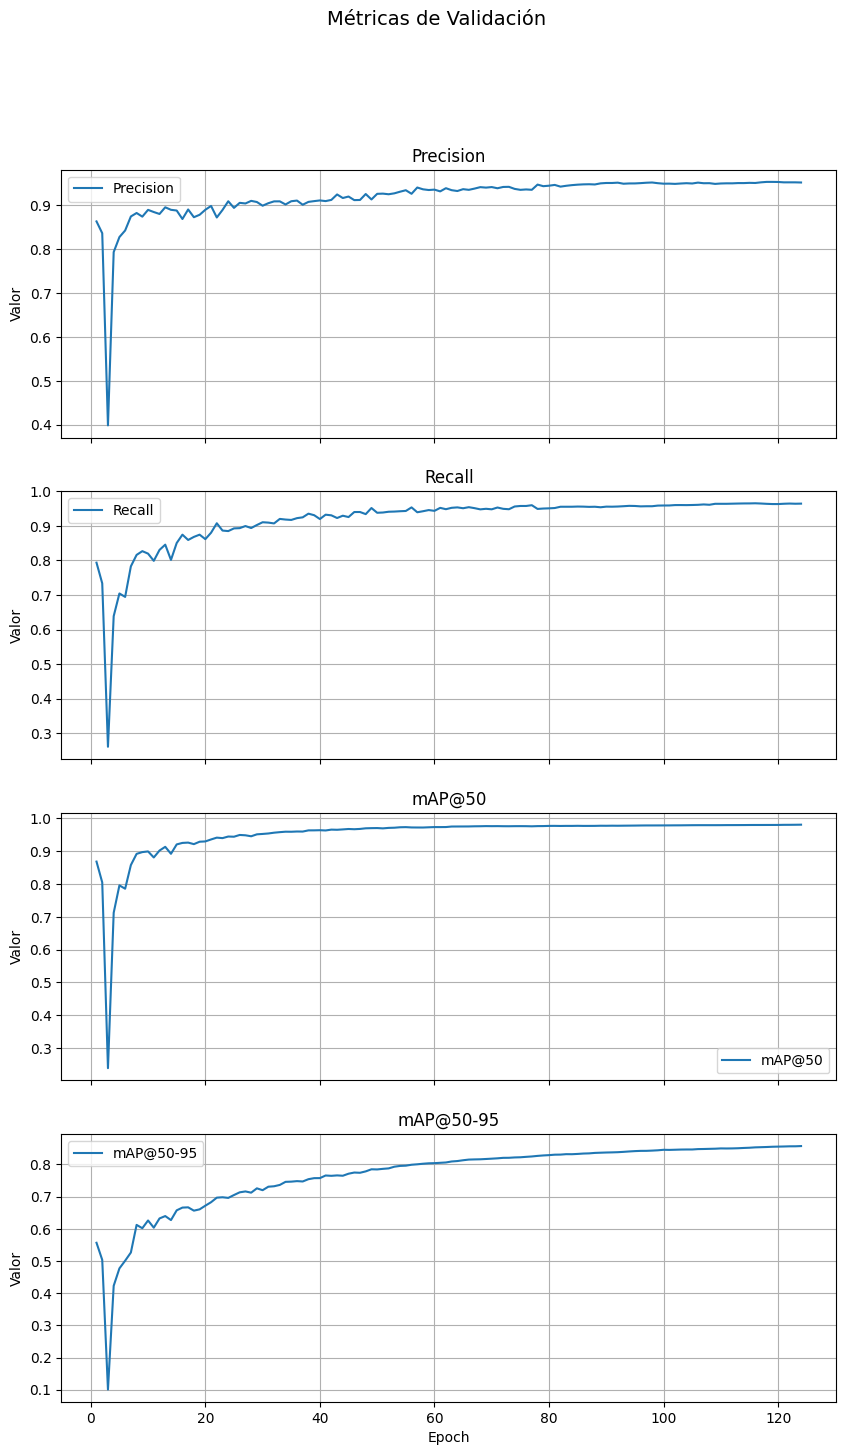

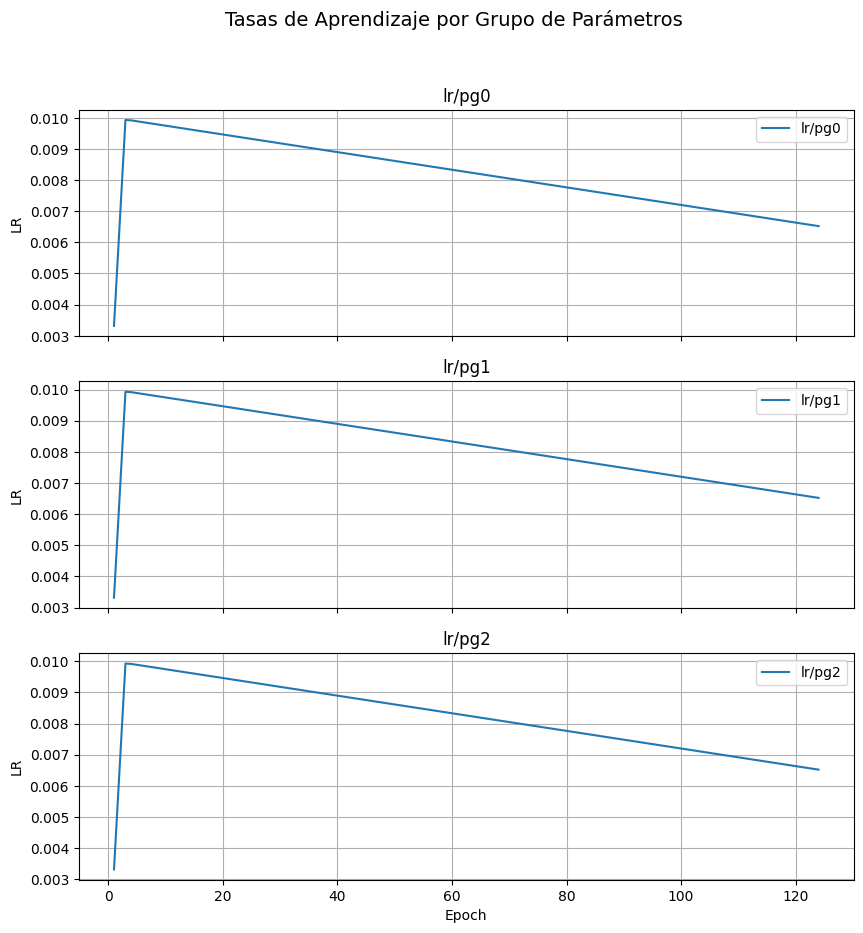

In [30]:
if SHOULD_TRAIN:
    try:
        viz = TrainingVisualizer(results_df)
        viz.plot_all()
    except Exception as e:
        LOGGER.error(f"Error al visualizar resultados: {e}")

#### Validación

In [ ]:
if SHOULD_TRAIN:
    try:
        metrics = model.val(
            project=EXPERIMENT_PATH, data=str(DATASET_PROCESSED_PATH / "dataset.yaml"), split="test", exist_ok=True
        )
        mAP50_95 = metrics.results_dict["metrics/mAP50-95(B)"]
        MODELS_PERFORMANCE_RESULTS.append(
            {
                "training_name": "full_training",
                "mAP50_95": mAP50_95,
                "model_path": str(EXPERIMENT_PATH / "train" / "weights" / "best.pt"),
            }
        )
        pprint(metrics.summary())
    except Exception as e:
        LOGGER.error(f"Error al evaluar el modelo: {e}")

## Validación del mejor modelo

Cargamos el mejor modelo:

In [ ]:
best_model_path = None
if MODELS_PERFORMANCE_RESULTS:
    best_mAP50_95 = 0.0
    for result in MODELS_PERFORMANCE_RESULTS:
        if result["mAP50_95"] > best_mAP50_95:
            best_mAP50_95 = result["mAP50_95"]
            best_model_path = Path(result["model_path"])

    LOGGER.info(f"Mejor modelo: {best_model_path} con mAP50-95: {best_mAP50_95}")
    if best_model_path is None or not os.path.exists(best_model_path):
        LOGGER.error("No se encontró un modelo entrenado. Verifica que el entrenamiento se haya realizado correctamente.")
        sys.exit(1)
else:
    best_model_path = MODEL_FOLDER / "coco_palm_dataset_v1.1_rpw_detection_yolo11x_640_transfer_learning_1031e359fa4e49c4aca7ae4d9b05b538.pt"
best_model = YOLO(best_model_path)

Limpiamos la GPU:

In [ ]:
# GpuUtils.clean_gpu_usage()

Validamos el modelo:

In [ ]:
settings.update({"mlflow": False})
metrics = best_model.val(
    data=str(DATASET_PROCESSED_PATH / "dataset.yaml"),
    split="test",
    exist_ok=True
)

Imprimimos el reporte de validación:

In [ ]:
pprint(metrics.summary())

## Predicción

Descargamos la imagen de prueba:

In [ ]:
# # image_name = "barrioCanadaVictoria_20180801_dji_pc_3cm" # 319 Mb -> 5.47 min
# # image_name = "BarrioCasabo_20240419_dji_pc_5cm" # 265 Mb -> 2.15 min
# # image_name = "barrio3Ombues_20180801_dji_pc_3cm" # 190.4 Mb -> 3.32 min
# # image_name = "Sayago_FFCC_20210319_dji_5c" # 143 Mb -> 1.44 min
# # image_name = "BalconDelCerro_20240726_dji_rtk_5cm" # 100 Mb -> 50 s
# # image_name = "PlayadelCerro_20221118_dji_pc_5cm" # 66 Mb -> 51 s
# image_name = "8deOctubreyCentenario-EspLibreLarranaga_20190828_dji_pc_5cm"
# Path(DOWNLOAD_PREDICTION_FOLDER).mkdir(parents=True, exist_ok=True)
# image_metadata = ImageMetadata(image_name=image_name, group_id="GroupID1")
# image_file_path = DOWNLOAD_PREDICTION_FOLDER / f"{image_metadata.image_name}.jpg"
# ProcesadorS3.download_images_from_s3([image_metadata], DOWNLOAD_PREDICTION_FOLDER)
# LOGGER.debug(f"Se descargó la imagen {image_metadata.image_name} desde MinIO")

### Predicción normal

Realizamos la predicción normal:

In [ ]:
# result = best_model.predict(image_file_path)[0]

Obtenemos los resultados:

In [ ]:
# xywh = result.boxes.xywh  # center-x, center-y, width, height
# xywhn = result.boxes.xywhn  # normalized
# xyxy = result.boxes.xyxy  # top-left-x, top-left-y, bottom-right-x, bottom-right-y
# xyxyn = result.boxes.xyxyn  # normalized
# names = [result.names[cls.item()] for cls in result.boxes.cls.int()]  # class name of each box
# confs = result.boxes.conf  # confidence score of each box

# print(f"Resultados para la imagen: {image_name}")
# print(f"Cantidad de detecciones: {len(names)}")
# if len(names) == 0:
#     print("No se detectaron objetos.")
# else:
#     for i, (name, conf, box) in enumerate(zip(names, confs, xyxy)):
#         print(f"Detección {i+1}: Clase={name}, Confianza={conf.item():.2f}, Caja={box.tolist()}")

Filtramos los resultados según la confianza:

In [ ]:
# confidence_threshold = 0.50  # Ajusta según necesidad

# # Filtrar los índices según el umbral
# filtered_indices = [i for i, conf in enumerate(result.boxes.conf) if conf.item() >= confidence_threshold]

# # Filtrar las cajas y otros atributos
# filtered_boxes = result.boxes[filtered_indices]

# # Crear un nuevo objeto Results con las mismas propiedades pero solo con las detecciones filtradas
# results_filtered = Results(
#     orig_img=result.orig_img,
#     path=result.path,
#     names=result.names,
# )
# results_filtered.boxes = filtered_boxes
# results_filtered.orig_shape = result.orig_shape
# results_filtered.speed = result.speed
# results_filtered.save_dir = result.save_dir

Mostramos los resultados filtrados:

In [ ]:
# xywh = results_filtered.boxes.xywh  # center-x, center-y, width, height
# xywhn = results_filtered.boxes.xywhn  # normalized
# xyxy = results_filtered.boxes.xyxy  # top-left-x, top-left-y, bottom-right-x, bottom-right-y
# xyxyn = results_filtered.boxes.xyxyn  # normalized
# names = [results_filtered.names[cls.item()] for cls in results_filtered.boxes.cls.int()]  # class name of each box
# confs = results_filtered.boxes.conf  # confidence score of each box

# print(f"Resultados para la imagen: {image_name}")
# print(f"Cantidad de detecciones: {len(names)}")
# if len(names) == 0:
#     print("No se detectaron objetos.")
# else:
#     for i, (name, conf, box) in enumerate(zip(names, confs, xyxy)):
#         print(f"Detección {i+1}: Clase={name}, Confianza={conf.item():.2f}, Caja={box.tolist()}")

### Predicción SAHI

Aplicamos SAHI para mejorar la predicción:

In [ ]:
# model_predictor = DetectionModelPredictor(
#     model=best_model,
#     target_img_size_wh=(IMG_SIZE, IMG_SIZE),
#     overlap_ratio_wh=(0.4, 0.4),
#     overlap_filter_name="NMS",
#     iou_threshold=0.99,
# )
# predictions = model_predictor.predict(image_file_path)
# result_df = predictions.as_pandas()

Mostramos la imagen sin filtrar los resultados:

In [ ]:
# annotated_image = predictions.get_annotated_image(cv2.imread(str(image_file_path)))
# annotated_image_path = DOWNLOAD_PREDICTION_FOLDER / f"annotated_{image_file_path.name}_with_out_filtering.jpg"
# cv2.imwrite(str(annotated_image_path), annotated_image)

Probamos resultados filtrados con NMS 0.1:

In [ ]:
# predicions_aux = predictions.filter_by_nms(0.1)
# annotated_image = predicions_aux.get_annotated_image(cv2.imread(str(image_file_path)))
# annotated_image_path = DOWNLOAD_PREDICTION_FOLDER / f"annotated_{image_file_path.name}_with_nms01.jpg"
# cv2.imwrite(str(annotated_image_path), annotated_image)

Aplicamos NMM 0.1:

In [ ]:
# predicions_aux = predictions.filter_by_nmm(0.25)
# annotated_image = predicions_aux.get_annotated_image(cv2.imread(str(image_file_path)))
# annotated_image_path = DOWNLOAD_PREDICTION_FOLDER / f"annotated_{image_file_path.name}_with_nmm025.jpg"
# cv2.imwrite(str(annotated_image_path), annotated_image)

Aplicamos el pipeline de post-procesamiento final:

In [ ]:
# predictions = predictions.filter_by_nmm(0.20).filter_by_nms(0.20, class_agnostic=True).filter_by_confidence(0.5)
# annotated_image = predictions.get_annotated_image(cv2.imread(str(image_file_path)))
# annotated_image_path = DOWNLOAD_PREDICTION_FOLDER / f"annotated_{image_file_path.name}_output.jpg"
# cv2.imwrite(str(annotated_image_path), annotated_image)

Convertimos los resultados a anotaciones:

In [ ]:
# coco_annotations = predictions.as_coco_annotations(image_name, should_download=True)
# print("Anotaciones COCO:")
# pprint(coco_annotations)

Visualizamos los resultados:

In [ ]:
# coco_annotations_path = DOWNLOAD_COCO_ANNOTATIONS_FOLDER / "coco_annotations.json"
# VisualizadorCocoDataset.show_annotated_image_path(image_file_path, coco_annotations_path, image_name)

Mostramos los puntos:

In [ ]:
# predictions.as_pandas()

#### Generar KML

In [ ]:
# jgw_data = ProcesadorAnotacionesMongoDB.load_jgw_file_from_mongodb(image_name=image_name, should_download=True)
# pprint(jgw_data)

In [ ]:
# gdf = ProcesadorGeoJSONKML.create_geojson_from_annotations(image_name, coco_annotations, jgw_data, should_download=True)
# gdf.head()

In [ ]:
# kml = ProcesadorGeoJSONKML.generate_kml_from_geojson(gdf, should_download=True)

In [ ]:
# # Test
# kml_text = kml.to_string()
# gdf_test = ProcesadorGeoJSONKML.convert_kml_to_geojson(kml_text)